In [ ]:
import pandas as pd

df = pd.read_csv("synthetic_student_performance.csv")

print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

display(df.head())

Número de registros: 5000
Número de variables: 15


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,5000.0,3500.500000,1443.520003,1001.0,2250.750000,3500.500000,4750.250000,6000.0
Age,5000.0,16.485200,1.127136,15.0,15.000000,16.000000,18.000000,18.0
Gender,5000.0,0.510200,0.499946,0.0,0.000000,1.000000,1.000000,1.0
Ethnicity,5000.0,0.885400,1.038885,0.0,0.000000,0.000000,2.000000,3.0
ParentalEducation,5000.0,2.099400,1.229074,0.0,1.000000,2.000000,3.000000,4.0
StudyTimeWeekly,5000.0,10.031800,6.019438,0.0,5.000000,10.000000,15.000000,20.0
Absences,5000.0,15.065200,8.922223,0.0,8.000000,15.000000,23.000000,30.0
Tutoring,5000.0,0.312200,0.463437,0.0,0.000000,0.000000,1.000000,1.0
ParentalSupport,5000.0,2.296600,1.223817,0.0,2.000000,2.000000,3.000000,4.0
Extracurricular,5000.0,0.594800,0.490980,0.0,0.000000,1.000000,1.000000,1.0


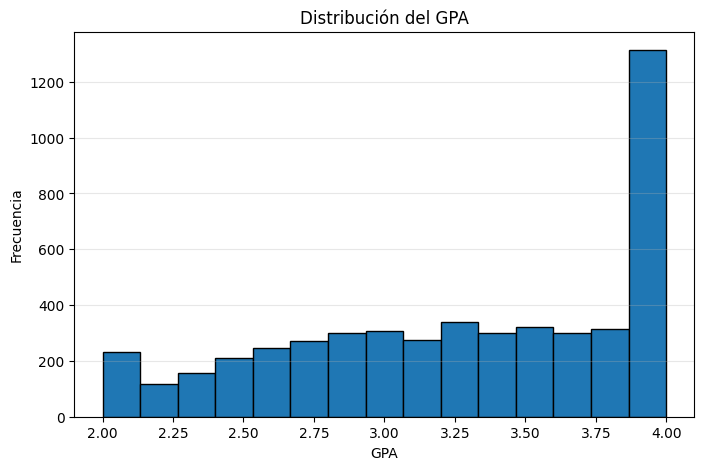

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["GPA"], bins=15, edgecolor="black")

plt.title("Distribución del GPA")
plt.xlabel("GPA")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 800x500 with 0 Axes>

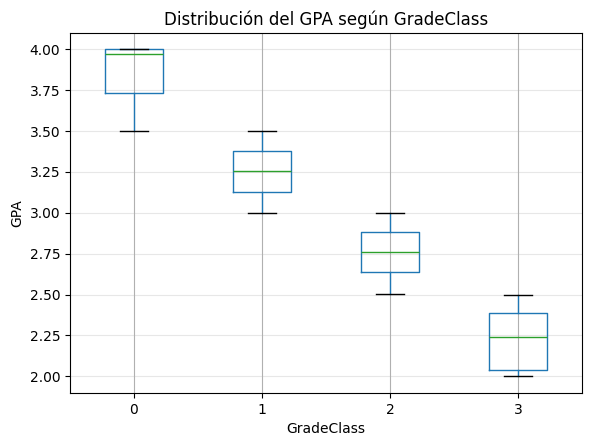

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="GPA", by="GradeClass")

plt.title("Distribución del GPA según GradeClass")
plt.suptitle("")
plt.xlabel("GradeClass")
plt.ylabel("GPA")
plt.grid(axis="y", alpha=0.3)

plt.show()

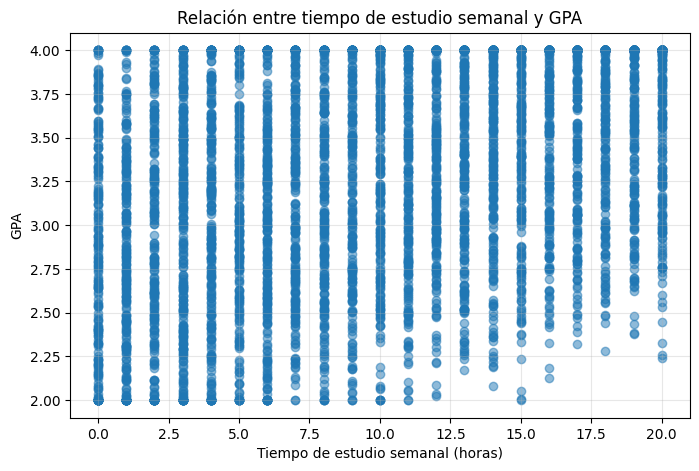

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["StudyTimeWeekly"], df["GPA"], alpha=0.5)

plt.title("Relación entre tiempo de estudio semanal y GPA")
plt.xlabel("Tiempo de estudio semanal (horas)")
plt.ylabel("GPA")
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Porcentaje de valores nulos por variable

nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resultado_nulos = pd.DataFrame({
    "Valores nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})

display(resultado_nulos)

,Valores nulos,Porcentaje (%)
StudentID,0,0.0
Age,0,0.0
Gender,0,0.0
Ethnicity,0,0.0
ParentalEducation,0,0.0
StudyTimeWeekly,0,0.0
Absences,0,0.0
Tutoring,0,0.0
ParentalSupport,0,0.0
Extracurricular,0,0.0


In [ ]:
# Cantidad y porcentaje de registros duplicados

duplicados = df.duplicated().sum()
porcentaje_duplicados = (duplicados / len(df)) * 100

print("Cantidad de registros duplicados:", duplicados)
print("Porcentaje de registros duplicados:", porcentaje_duplicados, "%")

Cantidad de registros duplicados: 0
Porcentaje de registros duplicados: 0.0 %


In [ ]:
# Identificación de valores atípicos mediante el método del IQR

variables = ["Age", "StudyTimeWeekly", "Absences", "GPA"]

outliers = {}

for variable in variables:
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad = ((df[variable] < limite_inferior) |
                (df[variable] > limite_superior)).sum()

    outliers[variable] = cantidad

resultado_outliers = pd.DataFrame(
    list(outliers.items()),
    columns=["Variable", "Cantidad de outliers"]
)

display(resultado_outliers)

,Variable,Cantidad de outliers
0,Age,0
1,StudyTimeWeekly,0
2,Absences,0
3,GPA,0


In [ ]:
# Verificación final de limpieza

print("Valores nulos totales:", df.isnull().sum().sum())
print("Registros duplicados:", df.duplicated().sum())
print("Número de registros:", len(df))

Valores nulos totales: 0
Registros duplicados: 0
Número de registros: 5000


In [ ]:
# Revisar los valores únicos de las variables categóricas

variables_categoricas = [
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
    "GradeClass"
]

for variable in variables_categoricas:
    print(f"{variable}: {sorted(df[variable].unique())}")

Gender: [np.int64(0), np.int64(1)]
Ethnicity: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
ParentalEducation: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Tutoring: [np.int64(0), np.int64(1)]
ParentalSupport: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Extracurricular: [np.int64(0), np.int64(1)]
Sports: [np.int64(0), np.int64(1)]
Music: [np.int64(0), np.int64(1)]
Volunteering: [np.int64(0), np.int64(1)]
GradeClass: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
# Eliminar StudentID por ser únicamente un identificador

df_modelo = df.drop(columns=["StudentID"])

print("Variables antes de eliminar StudentID:", df.shape[1])
print("Variables para el modelado:", df_modelo.shape[1])

display(df_modelo.head())

Variables antes de eliminar StudentID: 15
Variables para el modelado: 14


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [ ]:
from sklearn.preprocessing import StandardScaler

# Variables predictoras
X = df_modelo.drop(columns=["GradeClass"])

# Variable objetivo
y = df_modelo["GradeClass"]

# Aplicar estandarización
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
X_escalado = pd.DataFrame(X_escalado, columns=X.columns)

display(X_escalado.head())

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,0.456779,0.979804,0.110322,0.732820,0.991587,-0.231490,-0.673729,-0.242381,-1.211576,-0.827770,-0.660895,-0.658397,-0.207848
1,1.344072,0.979804,1.072988,-1.708287,1.157732,1.449873,-0.673729,-0.242381,0.825371,1.208064,1.513101,-0.658397,-0.804008
2,-1.317808,0.979804,-0.852345,-0.894584,0.493152,0.328964,1.484276,1.392014,-1.211576,-0.827770,-0.660895,1.518841,0.802366
3,0.456779,0.979804,-0.852345,0.732820,-0.669864,-1.240308,-0.673729,0.574817,0.825371,-0.827770,-0.660895,-0.658397,-0.400986
4,0.456779,-1.020612,0.110322,-0.080882,-0.669864,0.553146,-0.673729,1.392014,-1.211576,-0.827770,-0.660895,-0.658397,0.159062


In [ ]:
# Ingeniería de características

df_modelo["StudyAbsenceRatio"] = (
    df_modelo["StudyTimeWeekly"] / (df_modelo["Absences"] + 1)
)

df_modelo["ActivityCount"] = (
    df_modelo["Extracurricular"]
    + df_modelo["Sports"]
    + df_modelo["Music"]
    + df_modelo["Volunteering"]
)

# Mostrar las nuevas variables
display(
    df_modelo[
        [
            "StudyTimeWeekly",
            "Absences",
            "StudyAbsenceRatio",
            "Extracurricular",
            "Sports",
            "Music",
            "Volunteering",
            "ActivityCount"
        ]
    ].head()
)

,StudyTimeWeekly,Absences,StudyAbsenceRatio,Extracurricular,Sports,Music,Volunteering,ActivityCount
0,16,13,1.142857,0,0,0,0,0
1,17,28,0.586207,1,1,1,0,3
2,13,18,0.684211,0,0,0,1,1
3,6,4,1.200000,1,0,0,0,1
4,6,20,0.285714,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

# Variables predictoras y variable objetivo
X = df_modelo.drop(columns=["GradeClass"])
y = df_modelo["GradeClass"]

# División: 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Registros totales:", len(X))
print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

Registros totales: 5000
Registros de entrenamiento: 4000
Registros de prueba: 1000


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Crear el modelo
modelo_arbol = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Entrenar el modelo
modelo_arbol.fit(X_train, y_train)

# Realizar predicciones
y_pred_arbol = modelo_arbol.predict(X_test)

print("Modelo Árbol de Decisión entrenado correctamente.")
print("Número de predicciones:", len(y_pred_arbol))

Modelo Árbol de Decisión entrenado correctamente.
Número de predicciones: 1000


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Crear el modelo
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42
)

# Entrenar el modelo
modelo_random_forest.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = modelo_random_forest.predict(X_test)

print("Modelo Random Forest entrenado correctamente.")
print("Número de predicciones:", len(y_pred_rf))

Modelo Random Forest entrenado correctamente.
Número de predicciones: 1000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Crear el modelo
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski"
)

# Entrenar el modelo
modelo_knn.fit(X_train, y_train)

# Realizar predicciones
y_pred_knn = modelo_knn.predict(X_test)

print("Modelo KNN entrenado correctamente.")
print("Número de predicciones:", len(y_pred_knn))

Modelo KNN entrenado correctamente.
Número de predicciones: 1000


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Calcular métricas para cada modelo
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol, average="weighted")

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")

# Mostrar resultados
print("Decision Tree")
print("Accuracy:", accuracy_arbol)
print("F1-score:", f1_arbol)

print("\nRandom Forest")
print("Accuracy:", accuracy_rf)
print("F1-score:", f1_rf)

print("\nKNN")
print("Accuracy:", accuracy_knn)
print("F1-score:", f1_knn)

Decision Tree
Accuracy: 1.0
F1-score: 1.0

Random Forest
Accuracy: 0.992
F1-score: 0.9919495708969394

KNN
Accuracy: 0.531
F1-score: 0.5016566339610905


In [ ]:
print(df[["GPA", "GradeClass"]].head(10))

print("\nPromedio de GPA por GradeClass:")
display(df.groupby("GradeClass")["GPA"].agg(["min", "max", "mean"]))

        GPA  GradeClass
0  3.158425           1
1  2.794655           2
2  3.774847           0
3  3.040574           1
4  3.382310           1
5  4.000000           0
6  3.009268           1
7  4.000000           0
8  3.944525           0
9  2.735138           2

Promedio de GPA por GradeClass:


,min,max,mean
GradeClass,,,
0,3.501566,4.000000,3.865004
1,3.000244,3.499776,3.252358
2,2.500520,2.998432,2.760179
3,2.000000,2.499209,2.229993


In [ ]:
# Variables predictoras sin GPA
X = df_modelo.drop(columns=["GradeClass", "GPA"])

# Variable objetivo
y = df_modelo["GradeClass"]

print("Número de variables predictoras:", X.shape[1])
display(X.head())

Número de variables predictoras: 14


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,StudyAbsenceRatio,ActivityCount
0,17,1,1,3,16,13,0,2,0,0,0,0,1.142857,0
1,18,1,2,0,17,28,0,2,1,1,1,0,0.586207,3
2,15,1,0,1,13,18,1,4,0,0,0,1,0.684211,1
3,17,1,0,3,6,4,0,3,1,0,0,0,1.200000,1
4,17,0,1,2,6,20,0,4,0,0,0,0,0.285714,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Registros totales:", len(X))
print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

Registros totales: 5000
Registros de entrenamiento: 4000
Registros de prueba: 1000


In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

y_pred_arbol = modelo_arbol.predict(X_test)

print("Modelo Árbol de Decisión entrenado correctamente.")
print("Número de predicciones:", len(y_pred_arbol))

Modelo Árbol de Decisión entrenado correctamente.
Número de predicciones: 1000


In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42
)

modelo_random_forest.fit(X_train, y_train)

y_pred_rf = modelo_random_forest.predict(X_test)

print("Modelo Random Forest entrenado correctamente.")
print("Número de predicciones:", len(y_pred_rf))

Modelo Random Forest entrenado correctamente.
Número de predicciones: 1000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski"
)

modelo_knn.fit(X_train, y_train)

y_pred_knn = modelo_knn.predict(X_test)

print("Modelo KNN entrenado correctamente.")
print("Número de predicciones:", len(y_pred_knn))

Modelo KNN entrenado correctamente.
Número de predicciones: 1000


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Métricas del Árbol de Decisión
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
f1_arbol = f1_score(y_test, y_pred_arbol, average="weighted")

# Métricas de Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

# Métricas de KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")

print("RESULTADOS DE LOS MODELOS")
print("--------------------------")
print(f"Árbol de Decisión - Accuracy: {accuracy_arbol:.4f} | F1: {f1_arbol:.4f}")
print(f"Random Forest     - Accuracy: {accuracy_rf:.4f} | F1: {f1_rf:.4f}")
print(f"KNN               - Accuracy: {accuracy_knn:.4f} | F1: {f1_knn:.4f}")

RESULTADOS DE LOS MODELOS
--------------------------
Árbol de Decisión - Accuracy: 0.4660 | F1: 0.3757
Random Forest     - Accuracy: 0.4550 | F1: 0.3700
KNN               - Accuracy: 0.4320 | F1: 0.3967


In [ ]:
from sklearn.model_selection import cross_val_score

# Validación cruzada con 5 particiones
cv_arbol = cross_val_score(modelo_arbol, X, y, cv=5, scoring="accuracy")
cv_rf = cross_val_score(modelo_random_forest, X, y, cv=5, scoring="accuracy")
cv_knn = cross_val_score(modelo_knn, X, y, cv=5, scoring="accuracy")

print("VALIDACIÓN CRUZADA - 5 FOLDS")
print("-----------------------------")
print(f"Árbol de Decisión: {cv_arbol.mean():.4f}")
print(f"Random Forest:     {cv_rf.mean():.4f}")
print(f"KNN:               {cv_knn.mean():.4f}")

VALIDACIÓN CRUZADA - 5 FOLDS
-----------------------------
Árbol de Decisión: 0.4646
Random Forest:     0.4756
KNN:               0.4244
